In [1]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import src.data.loader as loader
import src.indicators.ema as ema
import src.strategies.strategies as strategies
import src.backtest as backtest
import src.reporting.notebook_views as views
    

# Investigating Half-Life Impact on Returns
We use a simple cross-over strategy with EMAs (Exponential Moving Averages) at
two different time-scales. 

## Initial Data Load

Number of data-points: 3775


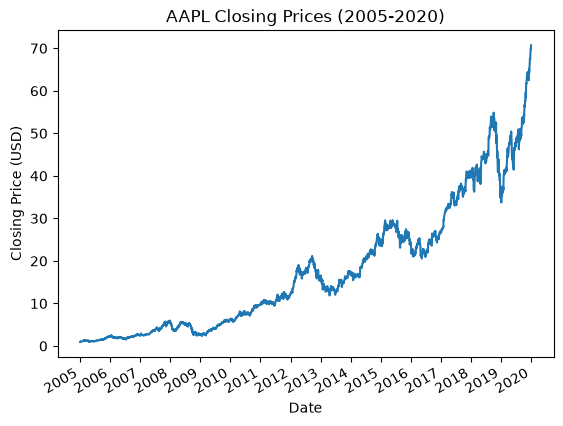

In [2]:
aapl_df = loader.get_prices(ticker="AAPL", start="2005-01-01", end="2020-01-01")
print(f"Number of data-points: {len(aapl_df)}")
fig = plt.plot(aapl_df.index, aapl_df['Close'])
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.gcf().autofmt_xdate()
plt.title("AAPL Closing Prices (2005-2020)")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.show()

## Computing and Plotting Some EMAs

We leave a 1600-day warm-up period for the EMAs. The highest half-lives we test
will be 200, so this ensures only a small tail of the exponential distribution
is omitted from the average.

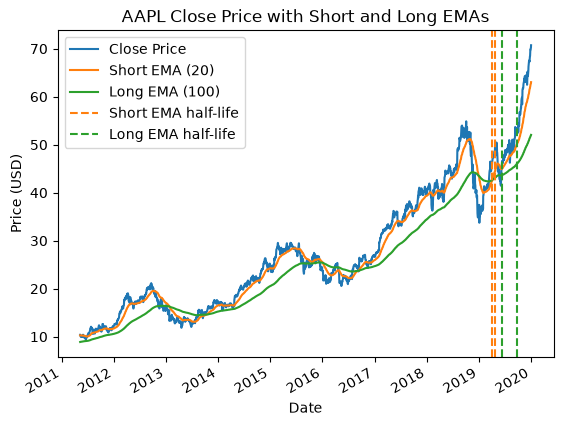

In [3]:
warmup_period = 1600
period = len(aapl_df) - warmup_period

short_ema = ema.get_ema_series(aapl_df, period=period, halflife=20)
long_ema = ema.get_ema_series(aapl_df, period=period, halflife=100)

l1 = plt.plot(aapl_df.index[warmup_period:], aapl_df['Close'].iloc[warmup_period:], color="tab:blue", label='Close Price')
l2 = plt.plot(aapl_df.index[warmup_period:], short_ema, color="tab:orange", label='Short EMA (20)')
l3 = plt.plot(aapl_df.index[warmup_period:], long_ema, color="tab:green", label='Long EMA (100)')
plt.axvline(x=aapl_df.index[-1] - pd.DateOffset(days=250), color='tab:orange', label='Short EMA half-life', linestyle='--')
plt.axvline(x=aapl_df.index[-1] - pd.DateOffset(days=270), color='tab:orange', linestyle='--')
plt.axvline(x=aapl_df.index[-1] - pd.DateOffset(days=100), color='tab:green', label='Long EMA half-life', linestyle='--')
plt.axvline(x=aapl_df.index[-1] - pd.DateOffset(days=200), color='tab:green', linestyle='--')

plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.gcf().autofmt_xdate()

plt.title("AAPL Close Price with Short and Long EMAs")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()

### Computing the Positions and Returns

We use the canonical half-lives and compare the results to a simple buy-and-hold 
benchmark. The benchmark has better returns, but higher annualized volatility,
resulting in lower Sharpe ratio.

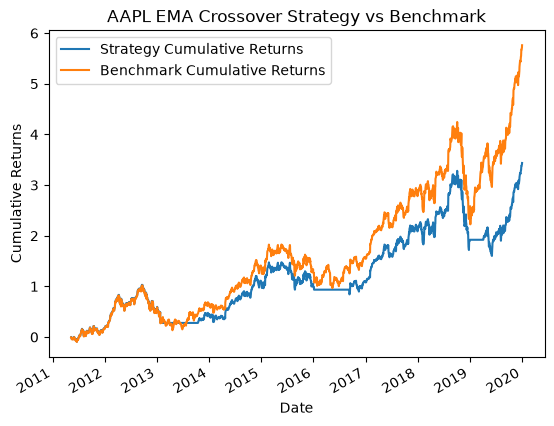

In [4]:
positions = strategies.get_ema_crossover_positions(short_ema, long_ema, long_only=True)
metrics, strategy_cumulative_returns, benchmark_cumulative_returns = backtest.compute_metrics_and_returns_from_positions_and_prices(positions, aapl_df)

views.render_metrics_grouped(metrics)
views.plot_cumulative_returns(strategy_cumulative_returns, benchmark_cumulative_returns, title="AAPL EMA Crossover Strategy vs Benchmark")

### Using a Long-Short strategy instead of Long-Only

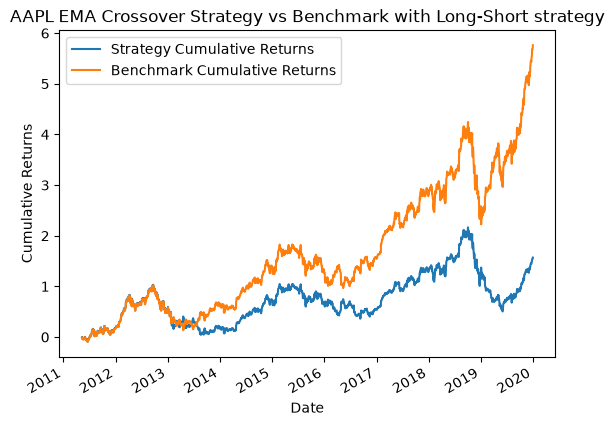

In [5]:
positions = strategies.get_ema_crossover_positions(short_ema, long_ema, long_only=False)
metrics, strategy_cumulative_returns, benchmark_cumulative_returns = backtest.compute_metrics_and_returns_from_positions_and_prices(positions, aapl_df)

views.render_metrics_grouped(metrics)
views.plot_cumulative_returns(strategy_cumulative_returns, benchmark_cumulative_returns, title="AAPL EMA Crossover Strategy vs Benchmark with Long-Short strategy")

The strategy gives a bearish signal throughout the middle of 2025, and this 
extends into the sudden upturn around October. This heavily punishes the simple 
long-short strategy, and is largely responsible for its underperforming both the
benchmark and the long-only strategy.

## Parameter Sweeps

We conduct parameter sweeps to observe the effect of varying both the short and
long timescales.

### Long time-scale

We sweep from a half-life of 200 business days to 30. 

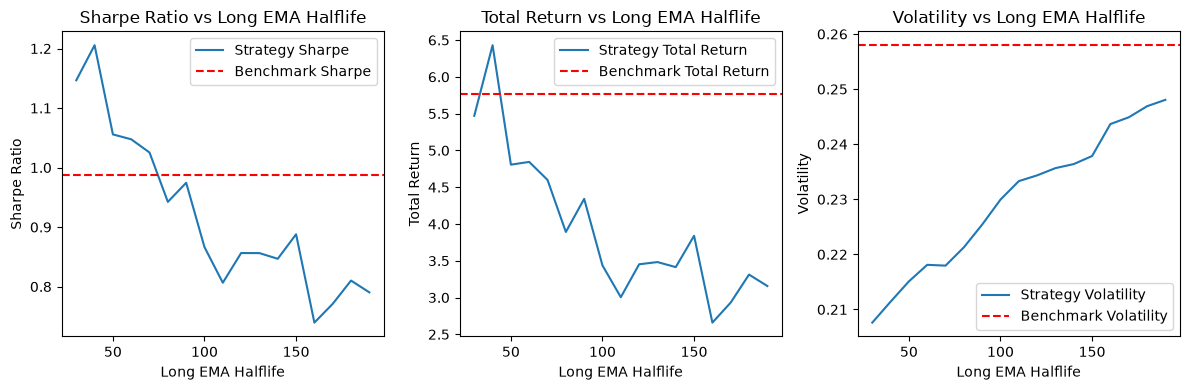

In [6]:
short_ema = ema.get_ema_series(aapl_df, period=period, halflife=20)
long_halflife_values = np.arange(30, 200, 10)
sharpe_list = np.empty(shape=len(long_halflife_values), dtype=np.float32)
total_return_list = np.empty(shape=len(long_halflife_values), dtype=np.float32)
volatility_list = np.empty(shape=len(long_halflife_values), dtype=np.float32)

for i, long_halflife in enumerate(long_halflife_values):
    long_ema = ema.get_ema_series(aapl_df, period=period, halflife=long_halflife)
    positions = strategies.get_ema_crossover_positions(short_ema, long_ema, long_only=True)
    metrics, _, _ = backtest.compute_metrics_and_returns_from_positions_and_prices(positions, aapl_df)
    sharpe_list[i] = metrics["strategy_sharpe"]
    total_return_list[i] = metrics["strategy_total_return"]
    volatility_list[i] = metrics["strategy_annualized_volatility"]

benchmark_total_return = metrics["benchmark_total_return"]
benchmark_sharpe = metrics["benchmark_sharpe"]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].plot(long_halflife_values, sharpe_list, label='Strategy Sharpe')
axes[0].axhline(y=benchmark_sharpe, color='r', linestyle='--', label='Benchmark Sharpe')
axes[0].set_title("Sharpe Ratio vs Long EMA Halflife")
axes[0].legend()
axes[0].set_xlabel("Long EMA Halflife")
axes[0].set_ylabel("Sharpe Ratio")
axes[1].plot(long_halflife_values, total_return_list, label='Strategy Total Return')
axes[1].axhline(y=benchmark_total_return, color='r', linestyle='--', label='Benchmark Total Return')
axes[1].set_title("Total Return vs Long EMA Halflife")
axes[1].set_xlabel("Long EMA Halflife")
axes[1].set_ylabel("Total Return")
axes[1].legend()
axes[2].plot(long_halflife_values, volatility_list, label='Strategy Volatility')
axes[2].axhline(y=metrics["benchmark_annualized_volatility"], color='r', linestyle='--', label='Benchmark Volatility')
axes[2].set_title("Volatility vs Long EMA Halflife")
axes[2].set_xlabel("Long EMA Halflife")
axes[2].set_ylabel("Volatility")
axes[2].legend()
plt.tight_layout()
plt.show()


### Short time-scale
We sweep from a half-life of 5 business days to 90

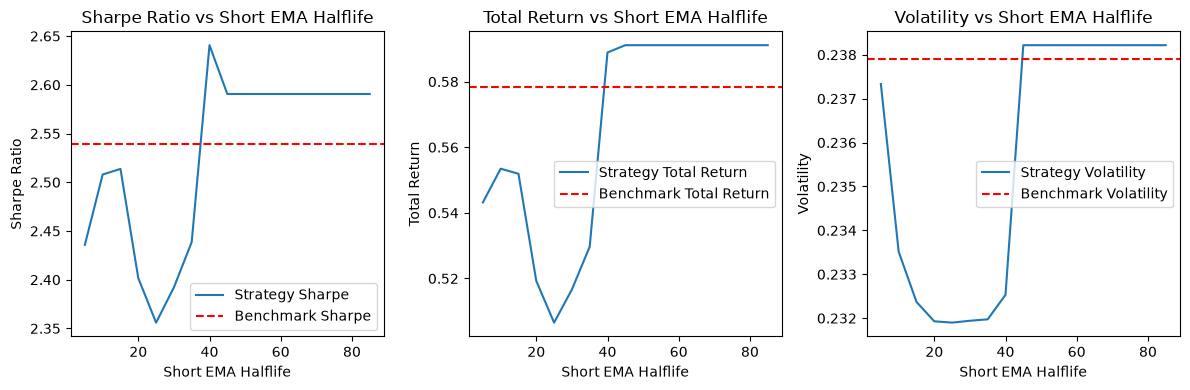

In [7]:
long_ema = ema.get_ema_series(aapl_df, period=200, halflife=100)
short_halflife_values = np.arange(5, 90, 5)
sharpe_list = np.empty(shape=len(short_halflife_values), dtype=np.float32)
total_return_list = np.empty(shape=len(short_halflife_values), dtype=np.float32)
volatility_list = np.empty(shape=len(short_halflife_values), dtype=np.float32)

for i, short_halflife in enumerate(short_halflife_values):
    short_ema = ema.get_ema_series(aapl_df, period=200, halflife=short_halflife)
    positions = strategies.get_ema_crossover_positions(short_ema, long_ema, long_only=True)
    metrics, _, _ = backtest.compute_metrics_and_returns_from_positions_and_prices(positions, aapl_df)
    sharpe_list[i] = metrics["strategy_sharpe"]
    total_return_list[i] = metrics["strategy_total_return"]
    volatility_list[i] = metrics["strategy_annualized_volatility"]

benchmark_total_return = metrics["benchmark_total_return"]
benchmark_sharpe = metrics["benchmark_sharpe"]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].plot(short_halflife_values, sharpe_list, label='Strategy Sharpe')
axes[0].axhline(y=benchmark_sharpe, color='r', linestyle='--', label='Benchmark Sharpe')
axes[0].set_title("Sharpe Ratio vs Short EMA Halflife")
axes[0].legend()
axes[0].set_xlabel("Short EMA Halflife")
axes[0].set_ylabel("Sharpe Ratio")
axes[1].plot(short_halflife_values, total_return_list, label='Strategy Total Return')
axes[1].axhline(y=benchmark_total_return, color='r', linestyle='--', label='Benchmark Total Return')
axes[1].set_title("Total Return vs Short EMA Halflife")
axes[1].set_xlabel("Short EMA Halflife")
axes[1].set_ylabel("Total Return")
axes[1].legend()
axes[2].plot(short_halflife_values, volatility_list, label='Strategy Volatility')
axes[2].axhline(y=metrics["benchmark_annualized_volatility"], color='r', linestyle='--', label='Benchmark Volatility')
axes[2].set_title("Volatility vs Short EMA Halflife")
axes[2].set_xlabel("Short EMA Halflife")
axes[2].set_ylabel("Volatility")
axes[2].legend()
plt.tight_layout()
plt.show()


## Bidimensional Sweep
An alternative strategy is to sweep across both parameters, to determine which combinations maximize Sharpe

In [8]:
short_halflife_values = np.arange(5, 195, 5)
long_halflife_values = np.arange(10, 200, 5)

rows = []
for short_index, short_halflife in enumerate(short_halflife_values):
    for long_index, long_halflife in enumerate(long_halflife_values):
        if long_halflife <= short_halflife:
            continue
        short_ema = ema.get_ema_series(aapl_df, period=200, halflife=short_halflife)
        long_ema = ema.get_ema_series(aapl_df, period=200, halflife=long_halflife)
        positions = strategies.get_ema_crossover_positions(short_ema, long_ema, long_only=True)
        metrics, _, _ = backtest.compute_metrics_and_returns_from_positions_and_prices(positions, aapl_df)
        rows.append({
            "short_halflife": short_halflife,
            "long_halflife": long_halflife,
            "strategy_sharpe": metrics["strategy_sharpe"],
            "strategy_total_return": metrics["strategy_total_return"],
            "strategy_annualized_volatility": metrics["strategy_annualized_volatility"],
            "ticker": "AAPL",
            "exposed_fraction": metrics["exposed_fraction"],
        })

aapl_grid_results = pd.DataFrame(rows)

Now we can use heatmaps to observe how each metric responds to different parameter values

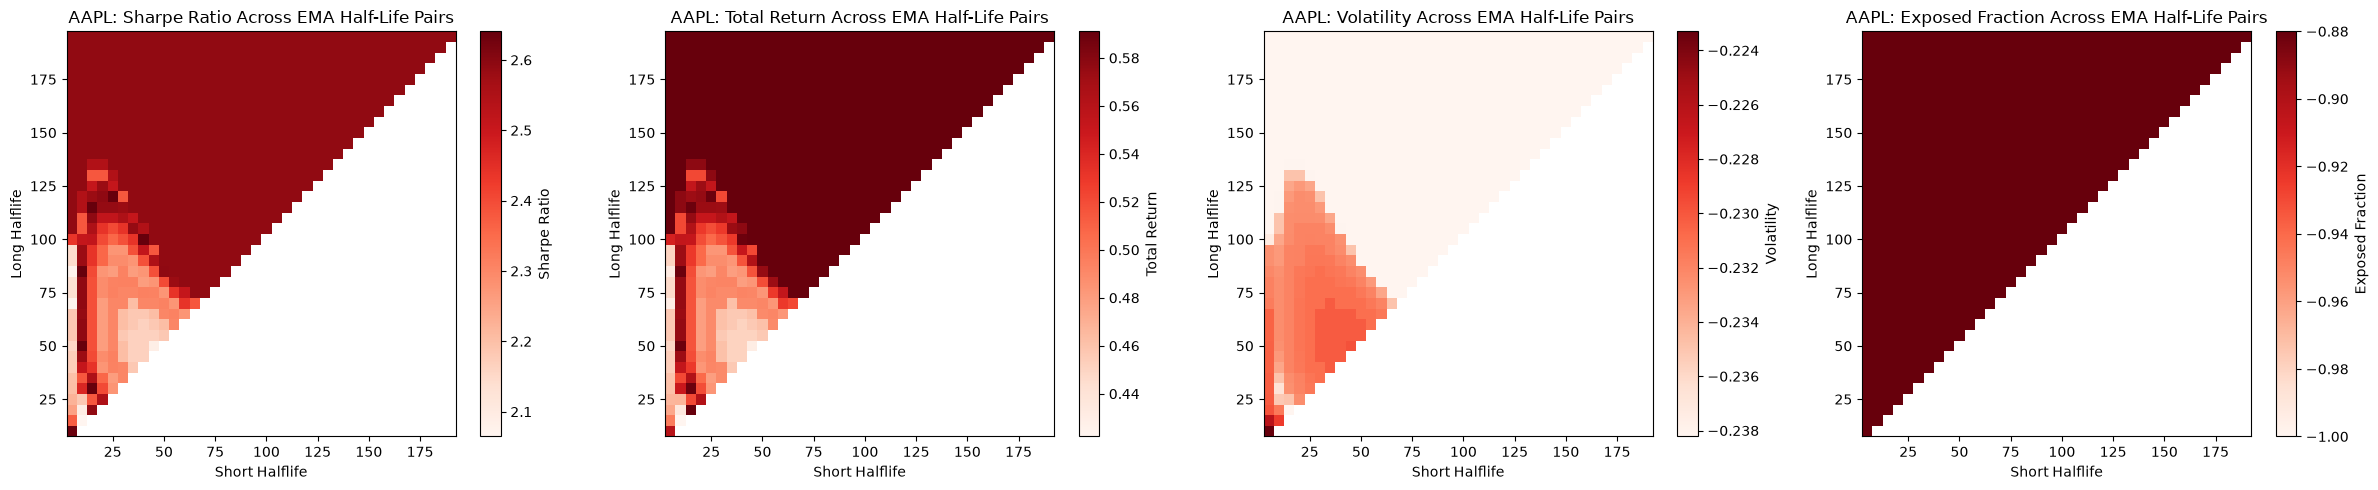

In [9]:
views.create_halflife_heatmaps_multi(aapl_grid_results)

## Other Securities

In [10]:
ticker_test_data = {
    "SPY": loader.get_prices(ticker="SPY", start="2005-01-01", end="2020-01-01"),
    "TLT": loader.get_prices(ticker="TLT", start="2005-01-01", end="2020-01-01"),
    "NVDA": loader.get_prices(ticker="NVDA", start="2005-01-01", end="2020-01-01"),
    "MSFT": loader.get_prices(ticker="MSFT", start="2005-01-01", end="2020-01-01"),
    "XOM": loader.get_prices(ticker="XOM", start="2005-01-01", end="2020-01-01"),
}
n_points = len(ticker_test_data["SPY"])
if not all(len(prices) == n_points for prices in ticker_test_data.values()):
    raise ValueError("All tickers must have the same number of data points.")
print(f"Number of data-points for each ticker: {n_points}")

test_tickers = list(ticker_test_data.keys())

Number of data-points for each ticker: 3775


We again use a 1600-day warmup period.

In [11]:
period = len(ticker_test_data["SPY"]) - warmup_period

short_halflife_values = np.arange(5, 195, 5)
long_halflife_values = np.arange(10, 200, 5)

def evaluate_ema_grid(ticker: str, data_df: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for short_halflife in short_halflife_values:
        for long_halflife in long_halflife_values:
            if long_halflife <= short_halflife:
                continue

            short_ema = ema.get_ema_series(data_df, period=period, halflife=short_halflife)
            long_ema = ema.get_ema_series(data_df, period=period, halflife=long_halflife)
            positions = strategies.get_ema_crossover_positions(short_ema, long_ema, long_only=True)
            metrics, _, _ = backtest.compute_metrics_and_returns_from_positions_and_prices(positions, data_df)

            rows.append({
                "ticker": ticker,
                "short_halflife": short_halflife,
                "long_halflife": long_halflife,
                "strategy_sharpe": metrics["strategy_sharpe"],
                "strategy_total_return": metrics["strategy_total_return"],
                "strategy_annualized_volatility": metrics["strategy_annualized_volatility"],
                "exposed_fraction": metrics["exposed_fraction"],
            })

    return pd.DataFrame(rows)

ema_grid_results = pd.concat(
    [evaluate_ema_grid(ticker, data_df) for ticker, data_df in ticker_test_data.items()],
    ignore_index=True,
)

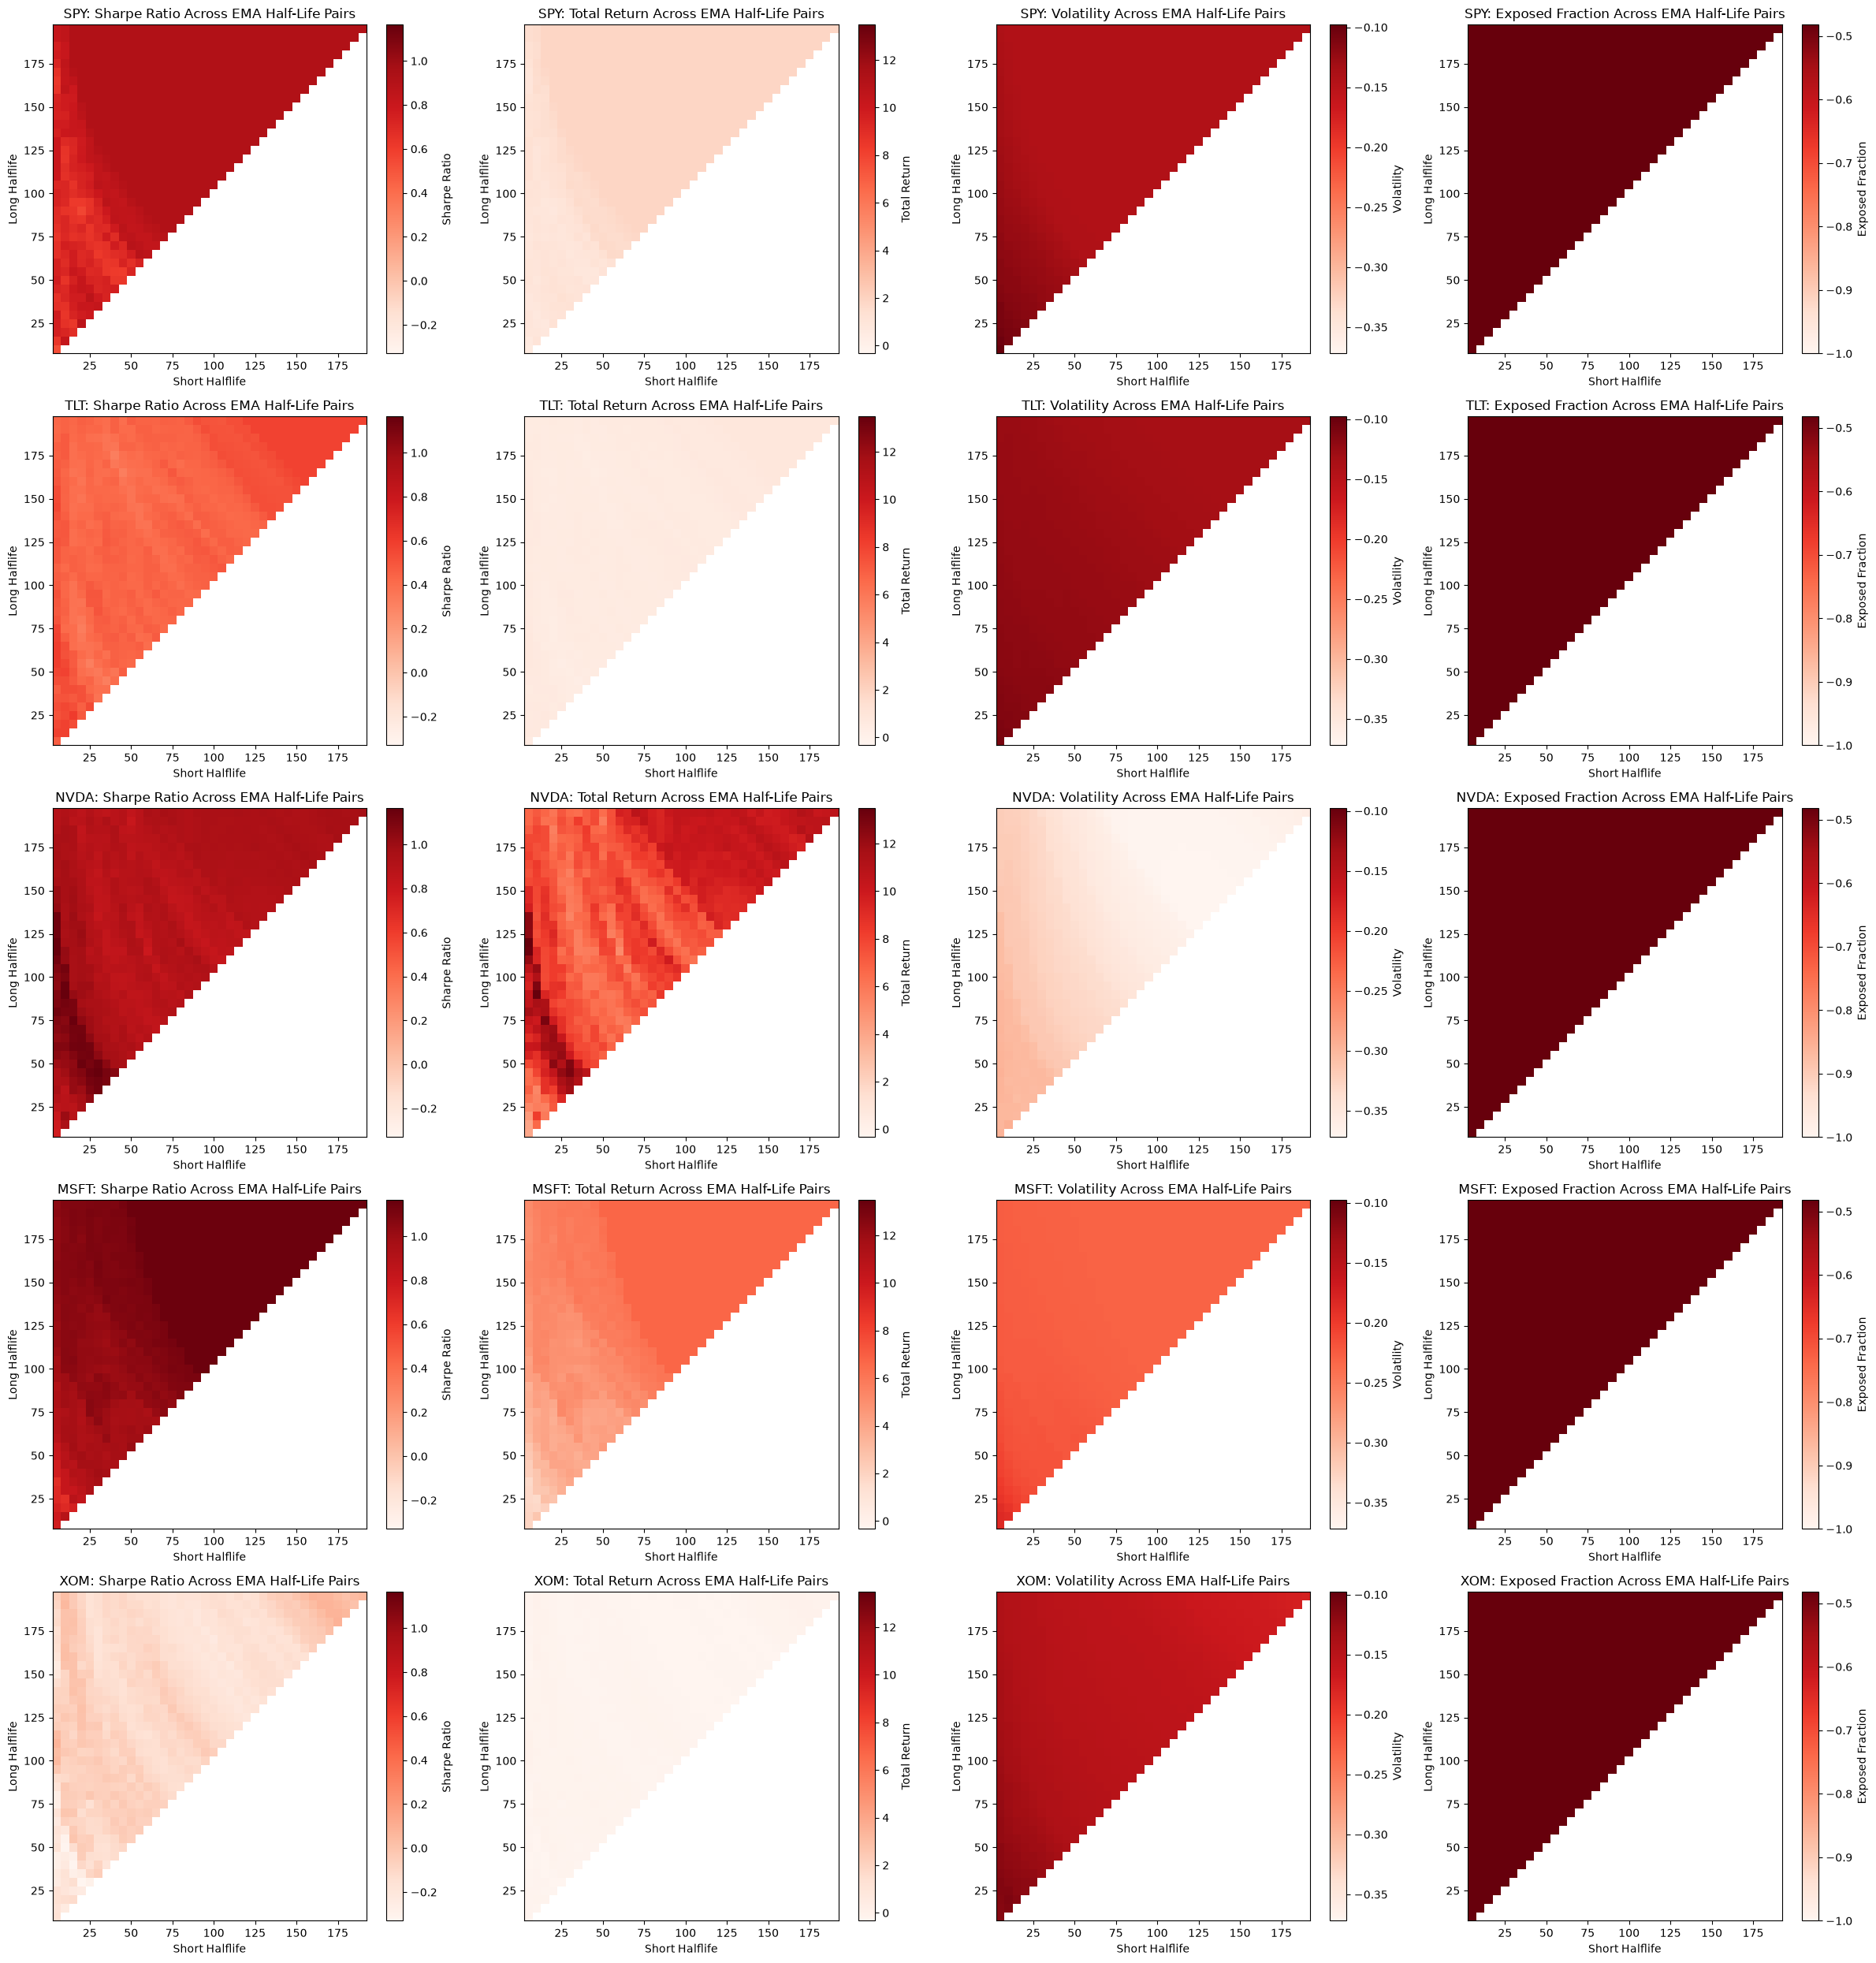

In [12]:
views.create_halflife_heatmaps_multi(ema_grid_results)

We can observe that SPY and MSFT have positive results for any large (both > ~100) 
half-life pair. Graphing the results for one such case with MSFT suggests that
these combinations result in a bullish signal always, resulting in a simple
"buy-and-hold".

For SPY and MSFT, the returns are large enough from always-holding that Sharpe
remains maximized for the always-long strategy, despite this strategy having
increased volatility.

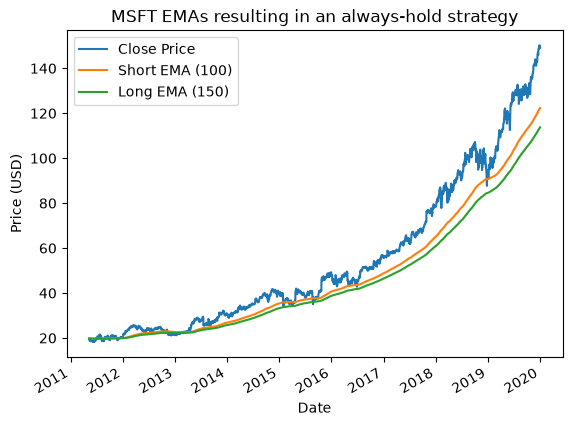

In [15]:
warmup_period = 1600

data_df = ticker_test_data['MSFT']
period = len(data_df) - warmup_period

short_ema = ema.get_ema_series(data_df, period=period, halflife=100)
long_ema = ema.get_ema_series(data_df, period=period, halflife=150)

views.plot_emas_and_price(data_df, short_ema, long_ema, warmup_period, 
                          title="MSFT EMAs resulting in an always-hold strategy", short_label="Short EMA (100)", long_label="Long EMA (150)")

To see if any patterns emerge, we can try averaging our results across all these securities.

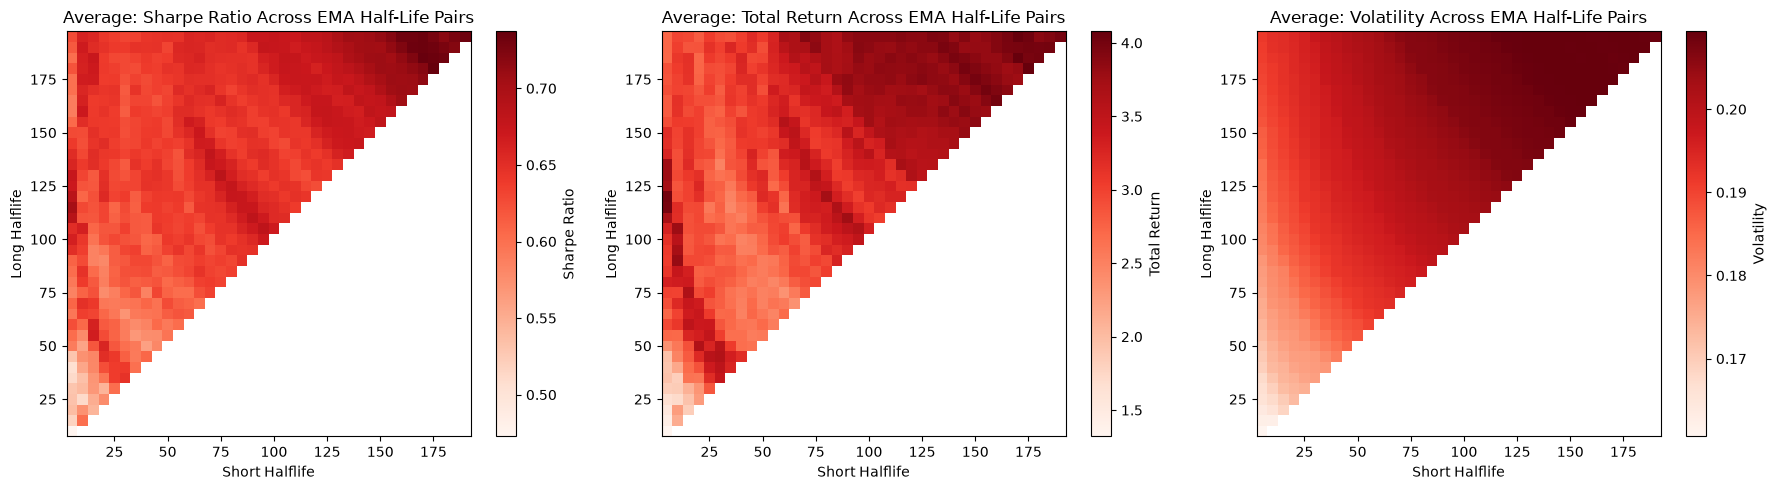

,short_halflife,long_halflife,strategy_sharpe,strategy_total_return,strategy_annualized_volatility,ticker
731,175,180,0.737204,4.072120,0.208945,Average
728,170,185,0.735484,4.069634,0.208935,Average
730,170,195,0.734073,4.078638,0.209299,Average
732,175,185,0.733178,3.978259,0.209063,Average
729,170,190,0.733178,3.978259,0.209063,Average
724,165,190,0.732639,3.967666,0.208995,Average
740,190,195,0.732440,3.987875,0.208838,Average
725,165,195,0.731411,3.975727,0.209048,Average
719,160,195,0.731302,3.912525,0.209016,Average
733,175,190,0.731077,3.995186,0.209265,Average


In [14]:
averaged_df = ema_grid_results.drop('ticker', axis=1).groupby(["short_halflife", "long_halflife"]).mean().reset_index()
averaged_df['ticker'] = "Average"
views.create_halflife_heatmaps_multi(averaged_df)
averaged_df.sort_values(by="strategy_sharpe", ascending=False).head(10)